In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

In [2]:
# LOAD DATA

from google.colab import files
import zipfile, os

# File picker - select file
uploaded = files.upload()

# Automatically zip file name detected
zip_name = list(uploaded.keys())[0]
print(f"Uploaded file: {zip_name}")

# Extraction
with zipfile.ZipFile(zip_name, "r") as z:
    print("Files inside zip:", z.namelist())
    z.extractall("/content/NSL_KDD")

print("Extraction done!")
print("Extracted files:", os.listdir("/content/NSL_KDD"))

Saving archive (1).zip to archive (1).zip
Uploaded file: archive (1).zip
Files inside zip: ['KDDTest+.arff', 'KDDTest+.txt', 'KDDTest-21.arff', 'KDDTest-21.txt', 'KDDTest1.jpg', 'KDDTrain+.arff', 'KDDTrain+.txt', 'KDDTrain+_20Percent.arff', 'KDDTrain+_20Percent.txt', 'KDDTrain1.jpg', 'index.html', 'nsl-kdd/KDDTest+.arff', 'nsl-kdd/KDDTest+.txt', 'nsl-kdd/KDDTest-21.arff', 'nsl-kdd/KDDTest-21.txt', 'nsl-kdd/KDDTest1.jpg', 'nsl-kdd/KDDTrain+.arff', 'nsl-kdd/KDDTrain+.txt', 'nsl-kdd/KDDTrain+_20Percent.arff', 'nsl-kdd/KDDTrain+_20Percent.txt', 'nsl-kdd/KDDTrain1.jpg', 'nsl-kdd/index.html']
Extraction done!
Extracted files: ['KDDTrain1.jpg', 'KDDTest+.txt', 'KDDTrain+.arff', 'nsl-kdd', 'index.html', 'KDDTrain+.txt', 'KDDTrain+_20Percent.txt', 'KDDTest1.jpg', 'KDDTest-21.arff', 'KDDTest-21.txt', 'KDDTrain+_20Percent.arff', 'KDDTest+.arff']


In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

# Training data
data = pd.read_csv("/content/NSL_KDD/KDDTrain+.txt", header=None, names=columns)

# Test data
test_data = pd.read_csv("/content/NSL_KDD/KDDTest+.txt", header=None, names=columns)

print(f"Train shape: {data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"\nLabel counts:\n{data['label'].value_counts()}")


Train shape: (125973, 43)
Test shape: (22544, 43)

Label counts:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [4]:
attack_map = {
    'normal': 'Normal',
    # DoS
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS',
    'teardrop': 'DoS', 'pod': 'DoS', 'land': 'DoS',
    'mailbomb': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe',
    'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L',
    'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L',
    'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'snmpguess': 'R2L', 'httptunnel': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

def map_attack(label):
    return attack_map.get(label, 'Unknown')   # flag unknowns explicitly

data['label'] = data['label'].apply(lambda x: attack_map.get(x, 'Unknown'))

print(data['label'].value_counts())

label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [5]:
label_encoders = {}
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le   # save for later use

In [6]:
data['traffic_intensity'] = data['count'] + data['srv_count']
data['login_anomaly']     = data['num_failed_logins'] + data['logged_in']
data['data_flow']         = data['src_bytes'] + data['dst_bytes']
data['error_ratio']       = data['serror_rate'] + data['rerror_rate']
data['host_diversity']    = data['dst_host_srv_count'] / (data['dst_host_count'] + 1)

print(f"Total features: {data.shape[1] - 2}")

Total features: 46


In [7]:
X = data.drop(['label', 'difficulty'], axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (100778, 46), Test: (25195, 46)


In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("Training complete!")

Training complete!


In [9]:
THRESHOLD = 0.6

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

max_confidences = np.max(y_prob, axis=1)
anomaly_mask    = max_confidences < THRESHOLD

print(f"High confidence: {(~anomaly_mask).sum()}")
print(f"Anomaly flagged: {anomaly_mask.sum()}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

High confidence: 25153
Anomaly flagged: 42

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       1.00      0.97      0.98       199
         U2R       0.88      0.70      0.78        10

    accuracy                           1.00     25195
   macro avg       0.97      0.93      0.95     25195
weighted avg       1.00      1.00      1.00     25195



In [10]:
# Test accuracy
train_pred = model.predict(X_train_scaled)
test_pred  = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

# print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")
print(f"Difference        : {abs(train_acc - test_acc):.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.9986
Difference        : 0.0013
✅ No overfitting — train aur test almost same hain


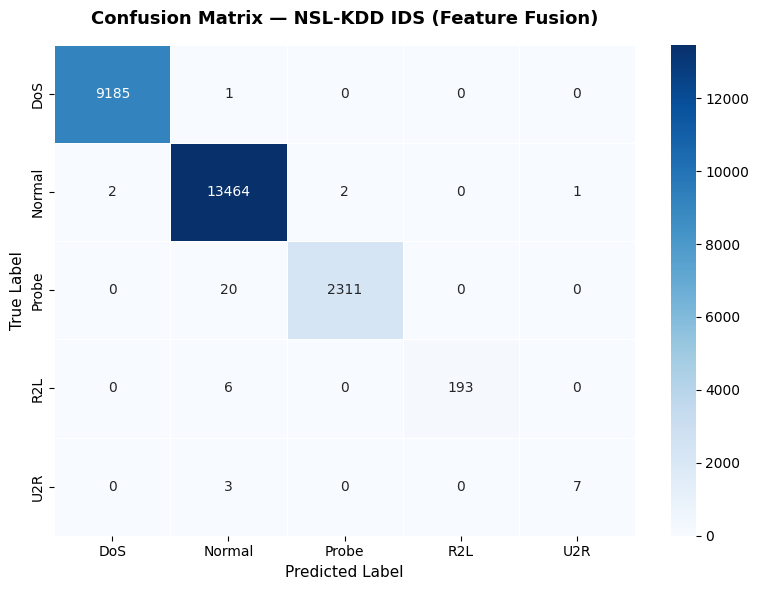

✅ Confusion matrix done!


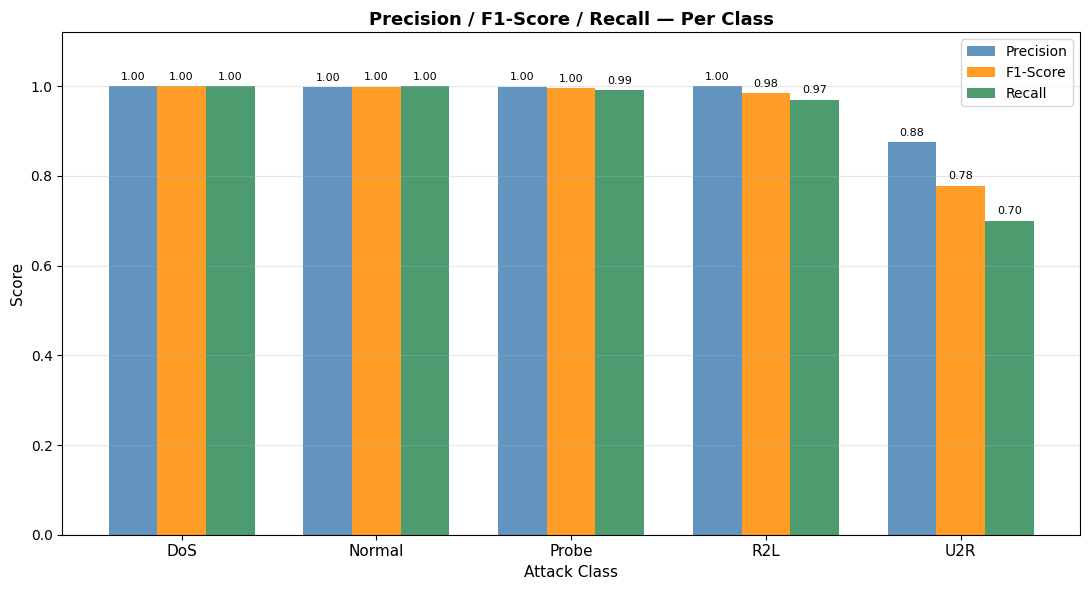

✅ Class metrics chart done!


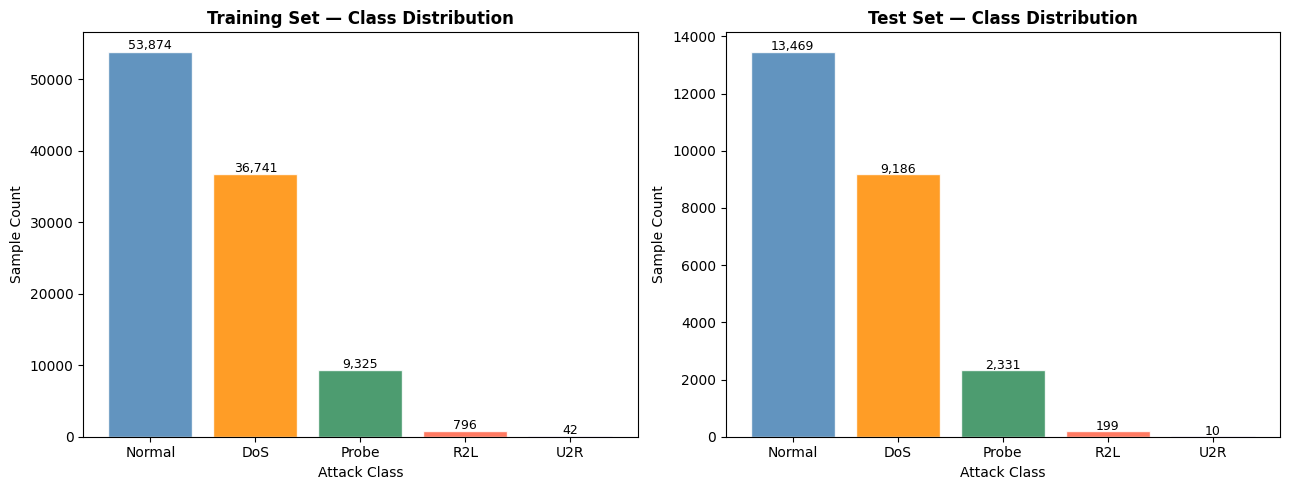

✅ Class distribution done!


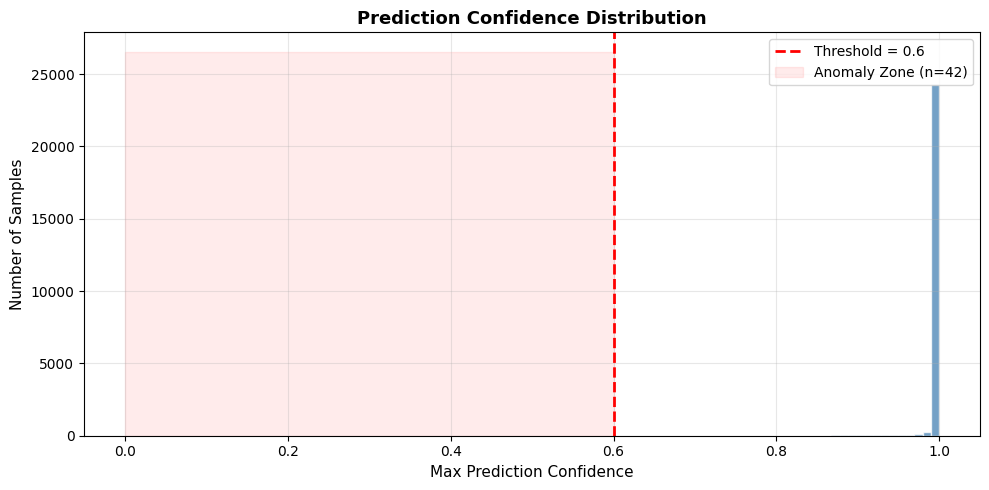

✅ Confidence distribution done!


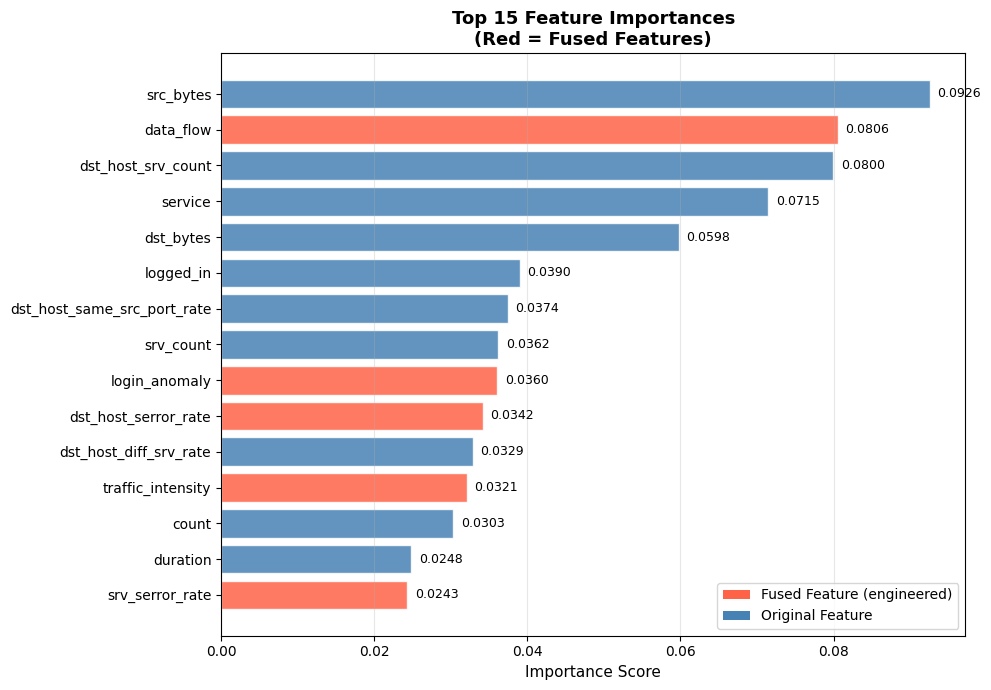

✅ Feature importance done!

📥 Downloading all graphs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Sabhi 5 graphs download ho gaye!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

classes = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title('Confusion Matrix — NSL-KDD IDS (Feature Fusion)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix done!")

# ── 2. PRECISION / RECALL / F1 BAR CHART ─────────────────────────
report = classification_report(y_test, y_pred, output_dict=True)

labels    = list(classes)
precision = [report[c]['precision'] for c in labels]
recall    = [report[c]['recall']    for c in labels]
f1        = [report[c]['f1-score']  for c in labels]

x     = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue',  alpha=0.85)
b2 = ax.bar(x,          f1,        width, label='F1-Score',  color='darkorange', alpha=0.85)
b3 = ax.bar(x + width,  recall,    width, label='Recall',    color='seagreen',   alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / F1-Score / Recall — Per Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class metrics chart done!")

# ── 3. CLASS DISTRIBUTION (TRAIN vs TEST) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'mediumpurple']

# Train
bars = axes[0].bar(train_counts.index, train_counts.values,
                   color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Training Set — Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Class', fontsize=10)
axes[0].set_ylabel('Sample Count', fontsize=10)
for bar, val in zip(bars, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=9)

# Test
bars2 = axes[1].bar(test_counts.index, test_counts.values,
                    color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Test Set — Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attack Class', fontsize=10)
axes[1].set_ylabel('Sample Count', fontsize=10)
for bar, val in zip(bars2, test_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution done!")

# ── 4. CONFIDENCE SCORE DISTRIBUTION ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

max_conf = np.max(y_prob, axis=1)
ax.hist(max_conf, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(x=0.6, color='red', linestyle='--', linewidth=2, label='Threshold = 0.6')
ax.fill_betweenx([0, ax.get_ylim()[1] + 1000], 0, 0.6,
                  alpha=0.08, color='red', label=f'Anomaly Zone (n=42)')

ax.set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Max Prediction Confidence', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confidence distribution done!")

# ── 5. FEATURE IMPORTANCE (TOP 15) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

importances = pd.Series(model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=True).tail(15)

colors_fi = ['tomato' if 'traffic' in i or 'login' in i or
             'data_flow' in i or 'error' in i or 'diversity' in i
             else 'steelblue' for i in top15.index]

bars = ax.barh(top15.index, top15.values, color=colors_fi, alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Feature Importances\n(Red = Fused Features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)

for bar, val in zip(bars, top15.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato',    label='Fused Feature (engineered)'),
                   Patch(facecolor='steelblue', label='Original Feature')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance done!")

# ── DOWNLOAD ALL ──────────────────────────────────────────────────
# from google.colab import files
# print("\n📥 Downloading all graphs...")
# for fname in ['confusion_matrix.png', 'class_metrics.png',
#               'class_distribution.png', 'confidence_dist.png',
#               'feature_importance.png']:
#     files.download(fname)

# print("\n🎉 Sabhi 5 graphs download ho gaye!")